In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

print(os.getcwd())

e:\MA_Target_Screening_ML\notebook


In [4]:
df = pd.read_excel('data/all_data.xlsx')

print(df.shape)

(3830, 32)


In [5]:
df.head()

,Unnamed: 0,Instrument,AD-250,AD-60,AD-30,AD,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",...,Net Debt per Share,Cash & Cash Equivalents - Total,Label,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,AR,Sales_growth
0,0,COR,2021-03-10,2021-09-16,2021-10-16,2021-11-15,40.21891,79309000.0,1.788389e+09,22.855325,...,39.991626,5543000.0,1,0.044347,0.005647,0.003099,51.388454,0.214218,-0.858267,8.048231
1,1,DVD,2021-03-04,2021-09-10,2021-10-10,2021-11-09,26.66113,7482000.0,6.902700e+07,25.492173,...,-0.345537,12568000.0,1,0.108392,0.031004,0.182074,12.643395,0.000000,-11.662717,-5.932295
2,2,MCFE.O,2021-03-03,2021-09-09,2021-10-09,2021-11-08,62.31934,-118000000.0,2.187000e+09,10.883691,...,8.768888,231000000.0,1,-0.053955,0.247075,0.105624,28.844474,0.194682,-12.960495,11.902193
3,3,CPLG.K,2021-03-03,2021-09-09,2021-10-09,2021-11-08,-10.70560,-178000000.0,1.682000e+09,-30.140187,...,11.758621,143000000.0,1,-0.105826,-0.150852,0.085018,-116.996230,0.587626,12.219687,-17.358218
4,4,MNR,2021-02-28,2021-09-06,2021-10-06,2021-11-05,81.96786,-22143000.0,1.912112e+09,49.471649,...,8.678789,23517000.0,1,-0.011580,-0.491178,0.012299,39.203266,0.262022,-0.604319,13.026745


In [6]:
df.isnull().sum()

Unnamed: 0                                                     0
Instrument                                                     0
AD-250                                                         0
AD-60                                                          0
AD-30                                                          0
AD                                                             0
Gross Profit Margin - %                                        0
Net Income after Minority Interest                             0
Total Capital                                                  0
Operating Margin - %, TTM                                      0
Free Cash Flow                                                 0
Revenue from Business Activities - Total                       0
Revenue from Business Activities - Total.1                     0
Revenue from Business Activities - Total.2                     0
Revenue from Business Activities - Total.3                     0
Current Ratio            

In [7]:
df.duplicated().sum()

0

In [8]:
df.isna().sum()

Unnamed: 0                                                     0
Instrument                                                     0
AD-250                                                         0
AD-60                                                          0
AD-30                                                          0
AD                                                             0
Gross Profit Margin - %                                        0
Net Income after Minority Interest                             0
Total Capital                                                  0
Operating Margin - %, TTM                                      0
Free Cash Flow                                                 0
Revenue from Business Activities - Total                       0
Revenue from Business Activities - Total.1                     0
Revenue from Business Activities - Total.2                     0
Revenue from Business Activities - Total.3                     0
Current Ratio            

In [9]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.drop(columns=['Instrument'], inplace=True)

In [10]:
df.head()

,AD-250,AD-60,AD-30,AD,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,...,Net Debt per Share,Cash & Cash Equivalents - Total,Label,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,AR,Sales_growth
0,2021-03-10,2021-09-16,2021-10-16,2021-11-15,40.21891,79309000.0,1.788389e+09,22.855325,3427000.0,6.068240e+08,...,39.991626,5543000.0,1,0.044347,0.005647,0.003099,51.388454,0.214218,-0.858267,8.048231
1,2021-03-04,2021-09-10,2021-10-10,2021-11-09,26.66113,7482000.0,6.902700e+07,25.492173,1195000.0,3.854300e+07,...,-0.345537,12568000.0,1,0.108392,0.031004,0.182074,12.643395,0.000000,-11.662717,-5.932295
2,2021-03-03,2021-09-09,2021-10-09,2021-11-08,62.31934,-118000000.0,2.187000e+09,10.883691,718000000.0,2.906000e+09,...,8.768888,231000000.0,1,-0.053955,0.247075,0.105624,28.844474,0.194682,-12.960495,11.902193
3,2021-03-03,2021-09-09,2021-10-09,2021-11-08,-10.70560,-178000000.0,1.682000e+09,-30.140187,-62000000.0,4.110000e+08,...,11.758621,143000000.0,1,-0.105826,-0.150852,0.085018,-116.996230,0.587626,12.219687,-17.358218
4,2021-02-28,2021-09-06,2021-10-06,2021-11-05,81.96786,-22143000.0,1.912112e+09,49.471649,-82428000.0,1.678170e+08,...,8.678789,23517000.0,1,-0.011580,-0.491178,0.012299,39.203266,0.262022,-0.604319,13.026745


In [11]:
print(df['Label'].value_counts())

Label
0    3648
1     182
Name: count, dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3830 entries, 0 to 3829
Data columns (total 30 columns):
 #   Column                                                       Non-Null Count  Dtype         
---  ------                                                       --------------  -----         
 0   AD-250                                                       3830 non-null   datetime64[ns]
 1   AD-60                                                        3830 non-null   datetime64[ns]
 2   AD-30                                                        3830 non-null   datetime64[ns]
 3   AD                                                           3830 non-null   datetime64[ns]
 4   Gross Profit Margin - %                                      3830 non-null   float64       
 5   Net Income after Minority Interest                           3830 non-null   float64       
 6   Total Capital                                                3830 non-null   float64       
 7   Operating Margi

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
AD-250,3830,2020-09-20 11:34:48.563968512,2020-01-09 00:00:00,2020-07-08 00:00:00,2020-10-10 00:00:00,2020-12-16 00:00:00,2021-03-10 00:00:00,NaN
AD-60,3830,2021-03-29 11:34:48.563968512,2020-07-17 00:00:00,2021-01-14 00:00:00,2021-04-18 00:00:00,2021-06-24 00:00:00,2021-09-16 00:00:00,NaN
AD-30,3830,2021-04-28 11:34:48.563968512,2020-08-16 00:00:00,2021-02-13 00:00:00,2021-05-18 00:00:00,2021-07-24 00:00:00,2021-10-16 00:00:00,NaN
AD,3830,2021-05-28 11:34:48.563968768,2020-09-15 00:00:00,2021-03-15 00:00:00,2021-06-17 00:00:00,2021-08-23 00:00:00,2021-11-15 00:00:00,NaN
Gross Profit Margin - %,3830.0,39.491474,-4827.14286,23.001022,39.43546,61.629948,460.71921,99.387238
Net Income after Minority Interest,3830.0,10346972674.943668,-553308372608.0,-18689500.0,4927000.0,123863000.0,27351280000000.0,451870439670.509766
Total Capital,3830.0,153566898665.351013,-2339000000.0,132554750.0,797629000.0,3679999500.0,265639567000000.0,4757786884293.279297
"Operating Margin - %, TTM",3830.0,-383.430843,-895591.22807,-3.412467,6.481775,15.721018,333.54164,15468.457661
Free Cash Flow,3830.0,5497603559.716867,-10465932000000.0,-6536750.0,16293000.0,179617250.0,22617255000000.0,406759823198.812073
Revenue from Business Activities - Total,3830.0,88909276633.570114,560.0,104213500.0,531932500.0,2589634750.0,110490033000000.0,2209656968240.335938


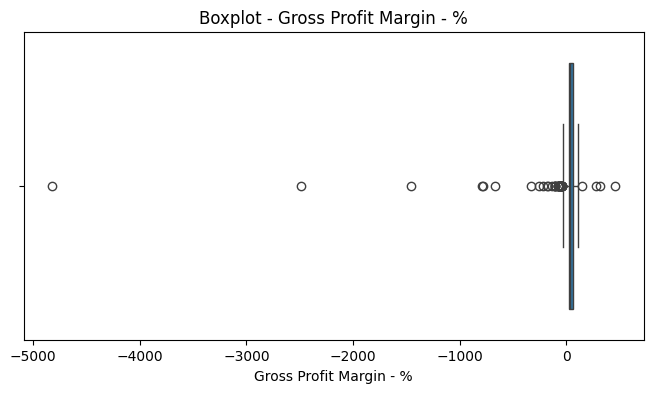

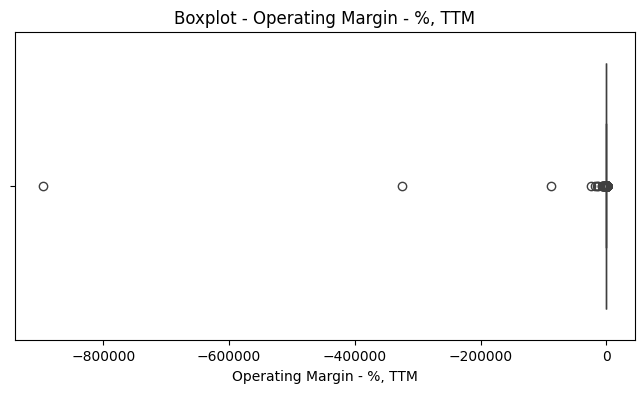

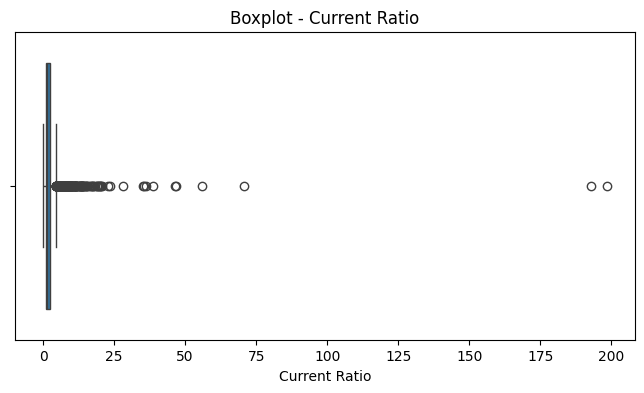

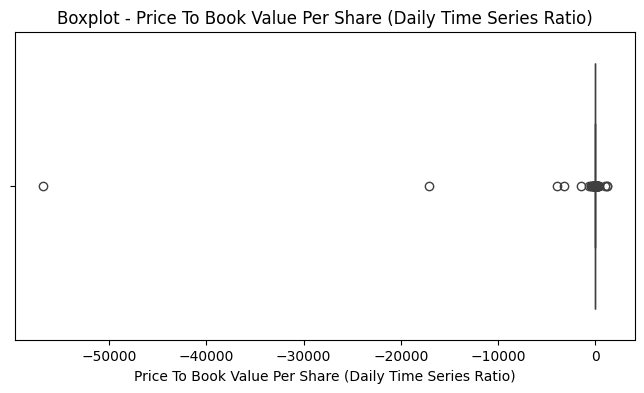

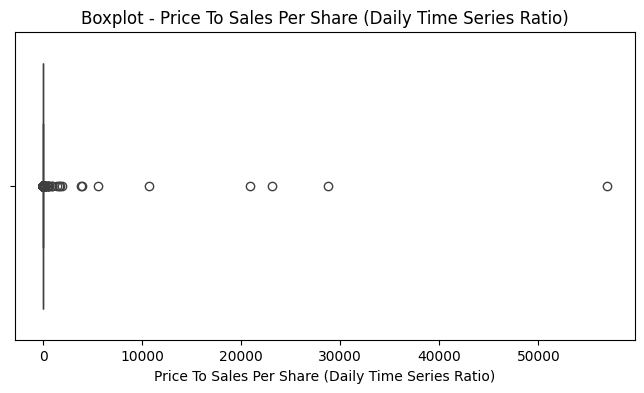

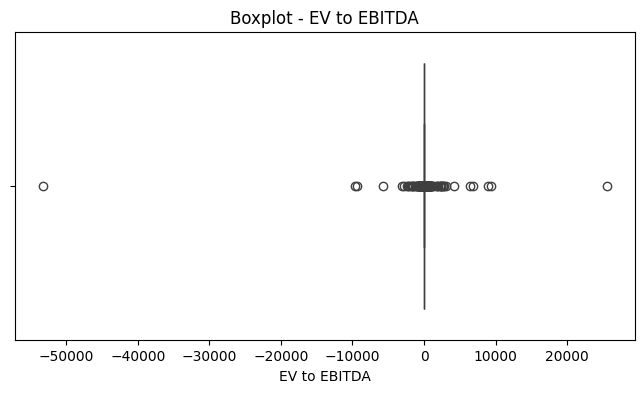

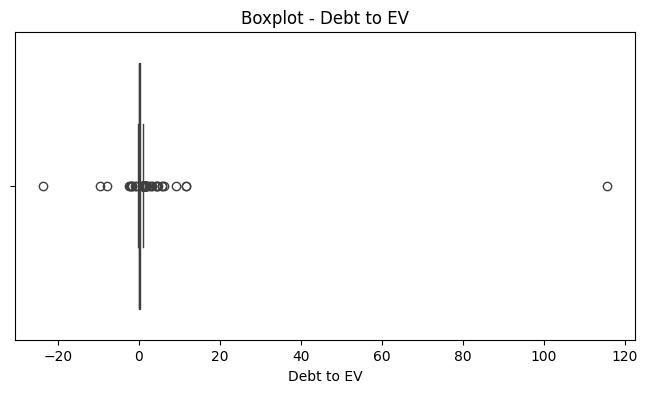

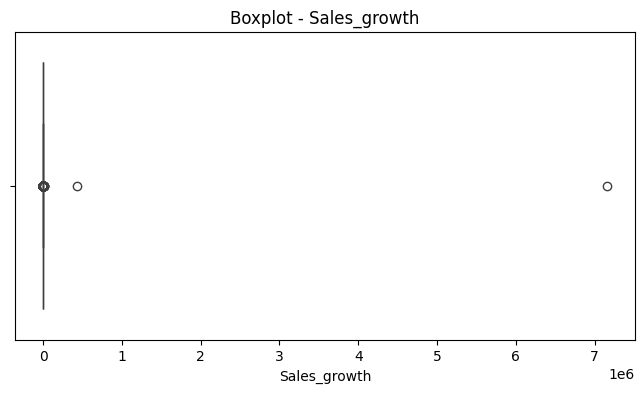

In [14]:
outlier_cols = [
    "Gross Profit Margin - %",
    "Operating Margin - %, TTM",
    "Current Ratio",
    "Price To Book Value Per Share (Daily Time Series Ratio)",
    "Price To Sales Per Share (Daily Time Series Ratio)",
    "EV to EBITDA",
    "Debt to EV",
    "Sales_growth"
]

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

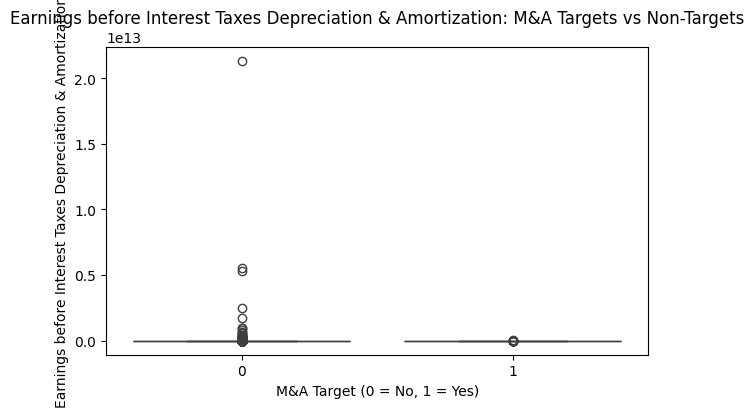

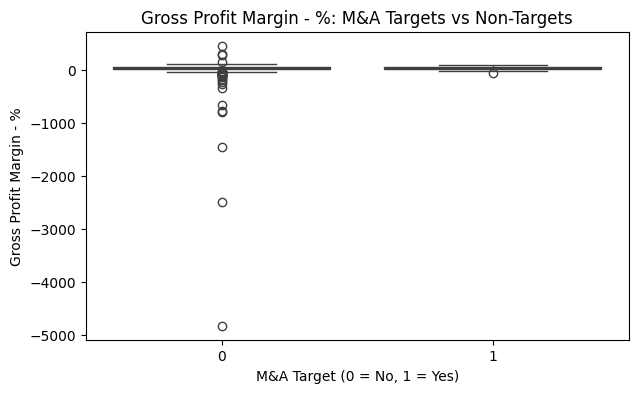

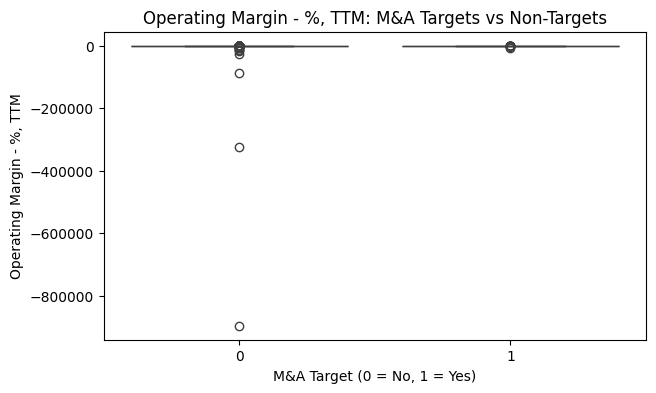

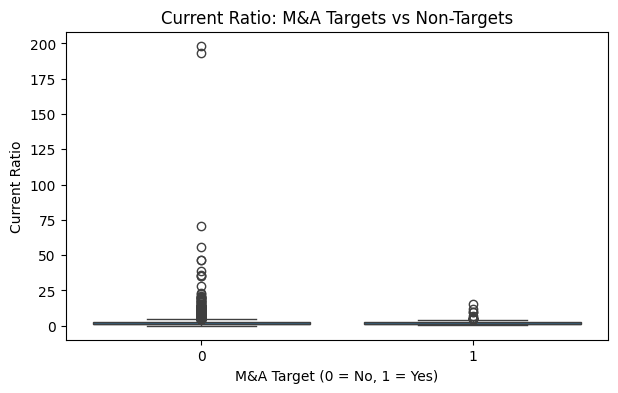

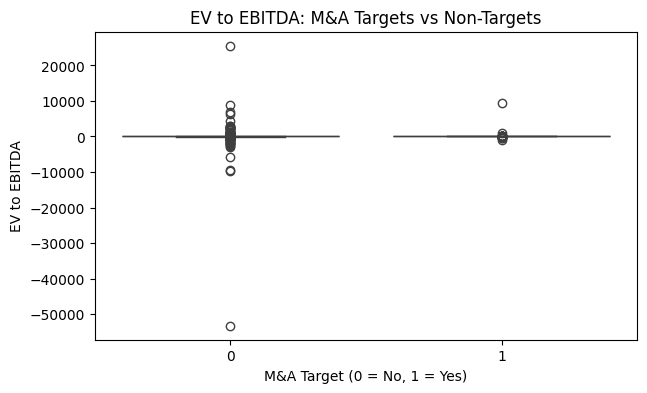

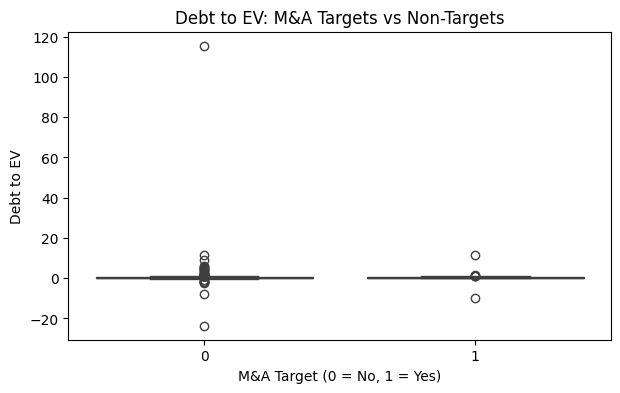

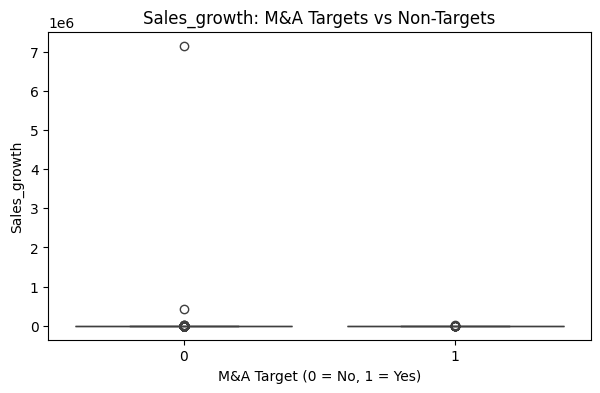

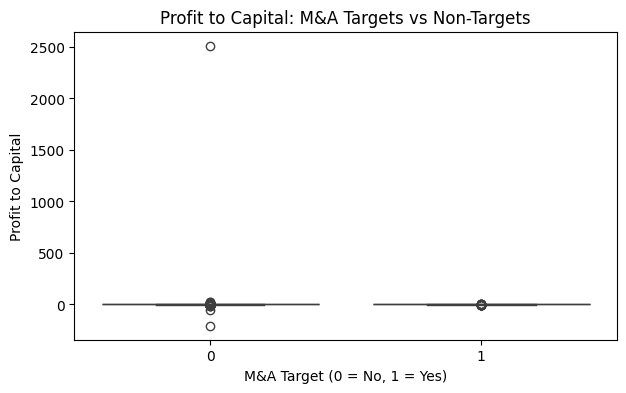

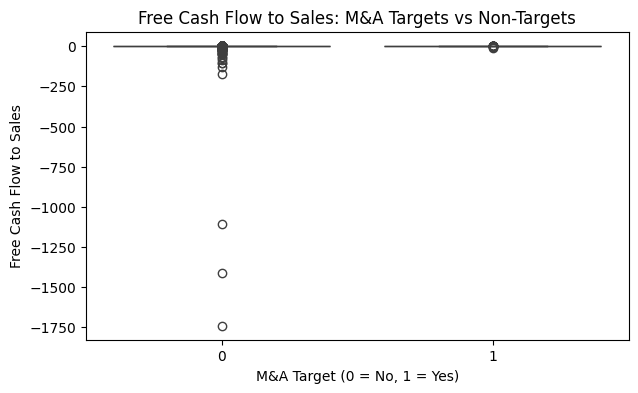

In [18]:
analysis_features = [
    "Earnings before Interest Taxes Depreciation & Amortization",
    "Gross Profit Margin - %",
    "Operating Margin - %, TTM",
    "Current Ratio",
    "EV to EBITDA",
    "Debt to EV",
    "Sales_growth",
    "Profit to Capital",
    "Free Cash Flow to Sales"
]

for col in analysis_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Label", y=col)
    plt.title(f"{col}: M&A Targets vs Non-Targets")
    plt.xlabel("M&A Target (0 = No, 1 = Yes)")
    plt.show()

In [15]:
df.corr()

,AD-250,AD-60,AD-30,AD,Gross Profit Margin - %,Net Income after Minority Interest,Total Capital,"Operating Margin - %, TTM",Free Cash Flow,Revenue from Business Activities - Total,...,Net Debt per Share,Cash & Cash Equivalents - Total,Label,Profit to Capital,Free Cash Flow to Sales,Cash to Capital,EV to EBITDA,Debt to EV,AR,Sales_growth
AD-250,1.000000,1.000000,1.000000,1.000000,-0.003135,-0.004911,-0.002295,-0.015718,0.000475,-0.000449,...,0.011570,-0.002901,-0.084366,0.007255,-0.017337,0.003425,0.016410,0.015083,0.014779,-0.029469
AD-60,1.000000,1.000000,1.000000,1.000000,-0.003135,-0.004911,-0.002295,-0.015718,0.000475,-0.000449,...,0.011570,-0.002901,-0.084366,0.007255,-0.017337,0.003425,0.016410,0.015083,0.014779,-0.029469
AD-30,1.000000,1.000000,1.000000,1.000000,-0.003135,-0.004911,-0.002295,-0.015718,0.000475,-0.000449,...,0.011570,-0.002901,-0.084366,0.007255,-0.017337,0.003425,0.016410,0.015083,0.014779,-0.029469
AD,1.000000,1.000000,1.000000,1.000000,-0.003135,-0.004911,-0.002295,-0.015718,0.000475,-0.000449,...,0.011570,-0.002901,-0.084366,0.007255,-0.017337,0.003425,0.016410,0.015083,0.014779,-0.029469
Gross Profit Margin - %,-0.003135,-0.003135,-0.003135,-0.003135,1.000000,-0.000605,-0.004076,0.261354,0.001460,-0.004955,...,-0.003138,-0.003909,0.007913,-0.004958,0.569989,0.007199,0.013283,-0.006690,-0.000717,-0.005142
Net Income after Minority Interest,-0.004911,-0.004911,-0.004911,-0.004911,-0.000605,1.000000,0.561813,0.000617,0.803814,0.676982,...,-0.002524,0.589096,-0.005100,-0.000213,0.001012,-0.000589,0.000405,-0.002730,0.000538,-0.000388
Total Capital,-0.002295,-0.002295,-0.002295,-0.002295,-0.004076,0.561813,1.000000,0.000812,-0.006697,0.980350,...,0.151645,0.989143,-0.007113,-0.000394,0.001256,-0.001023,0.001404,-0.000403,0.001193,-0.000556
"Operating Margin - %, TTM",-0.015718,-0.015718,-0.015718,-0.015718,0.261354,0.000617,0.000812,1.000000,0.000384,0.001020,...,0.000745,0.000794,0.005091,0.000179,0.661158,-0.000149,0.000501,0.003345,-0.001986,0.000157
Free Cash Flow,0.000475,0.000475,0.000475,0.000475,0.001460,0.803814,-0.006697,0.000384,1.000000,0.159929,...,0.009650,0.008090,-0.002954,-0.000095,0.000707,-0.000368,-0.000487,-0.001355,0.000130,-0.000226
Revenue from Business Activities - Total,-0.000449,-0.000449,-0.000449,-0.000449,-0.004955,0.676982,0.980350,0.001020,0.159929,1.000000,...,0.215239,0.971847,-0.008841,-0.000485,0.001595,-0.001106,0.001306,0.000138,0.001455,-0.000692
